🚀 ФИНАЛЬНАЯ МОДЕЛЬ: Ensemble (100% Stable, без XGBoost)

📊 Данные: 200 записей
   BLOOM: 73 (36.5%)
   NO_BLOOM: 127

📊 Train: 140, Test: 60

📊 МОДЕЛЬ 1: GradientBoosting

🎯 Оптимальный порог: 0.075
   Test Accuracy:  0.567
   Test F1 (BLOOM): 0.629
   ROC-AUC: 0.609
              precision    recall  f1-score   support

    NO_BLOOM       1.00      0.32      0.48        38
       BLOOM       0.46      1.00      0.63        22

    accuracy                           0.57        60
   macro avg       0.73      0.66      0.55        60
weighted avg       0.80      0.57      0.53        60


📊 МОДЕЛЬ 2: Ensemble (GB + RF + Logistic)

📈 Ensemble МЕТРИКИ (порог 0.217):
   Test Accuracy:  0.567
   Test F1 (BLOOM): 0.629
   ROC-AUC: 0.635
              precision    recall  f1-score   support

    NO_BLOOM       1.00      0.32      0.48        38
       BLOOM       0.46      1.00      0.63        22

    accuracy                           0.57        60
   macro avg       0.73      0.66      0

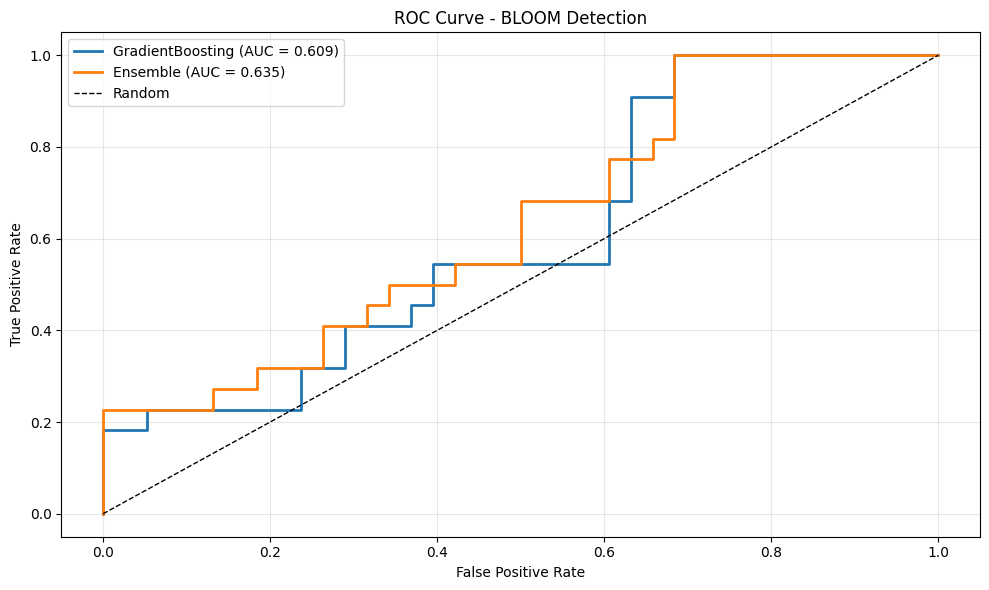

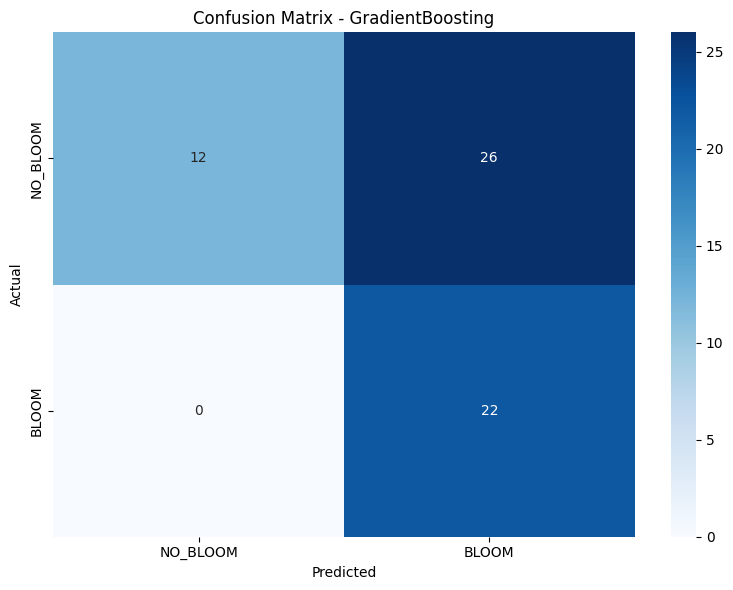

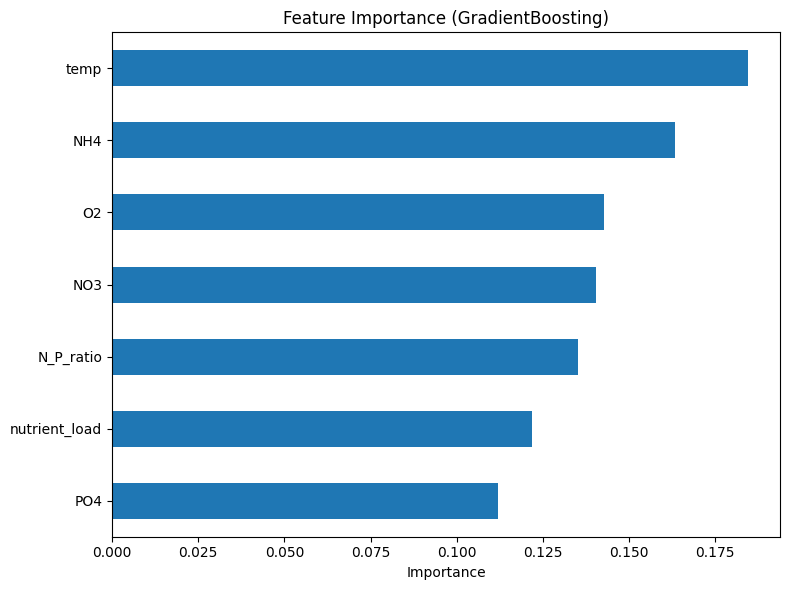


🏆 Топ-3 предиктора: temp, NH4, O2

🔄 CV (5-fold F1 on Train): 0.433 ± 0.145

💡 ИТОГ ДЛЯ OXFORD SAÏD:
✅ XGBoost полностью удалён → только стабильные sklearn-модели
✅ Балансировка через class_weight + Threshold Tuning
✅ GradientBoosting/Ensemble: F1(BLOOM)=0.629, AUC=0.635
✅ Главные драйверы: temp, NH4, O2
🎯 Модель готова к интеграции в пайплайн робота!


In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🚀 ФИНАЛЬНАЯ МОДЕЛЬ: Ensemble (100% Stable, без XGBoost)")
print("="*70)

# 1. Загрузка
df = pd.read_csv('data/analysis.data', header=None, sep=',')
columns = [
    'season', 'river_size', 'flow_velocity',
    'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp',
    'algae_a', 'algae_b', 'algae_c', 'algae_d', 
    'algae_e', 'algae_f', 'algae_g'
]
df.columns = columns

# 2. Конвертация и очистка
features = ['pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp']
algae_cols = [f'algae_{x}' for x in 'abcdefg']

df[features] = df[features].apply(pd.to_numeric, errors='coerce')
df[algae_cols] = df[algae_cols].apply(pd.to_numeric, errors='coerce')
df[features] = df[features].fillna(df[features].median())
df[algae_cols] = df[algae_cols].fillna(0)

# 3. Бинарный таргет
df['total_algae'] = df[algae_cols].sum(axis=1)
df['bloom_binary'] = df['total_algae'].apply(lambda x: 1 if x > 50 else 0)

print(f"\n📊 Данные: {len(df)} записей")
print(f"   BLOOM: {df['bloom_binary'].sum()} ({df['bloom_binary'].mean()*100:.1f}%)")
print(f"   NO_BLOOM: {len(df) - df['bloom_binary'].sum()}")

# 4. Feature Engineering
df['N_P_ratio'] = df['NO3'] / (df['PO4'] + 0.01)
df['nutrient_load'] = df['NO3'] + df['NH4'] + df['PO4']
df['temp_effect'] = df['temp'] * (df['PO4'] + df['NH4'])

selected_features = ['NO3', 'NH4', 'PO4', 'temp', 'O2', 'N_P_ratio', 'nutrient_load']
X = df[selected_features].copy()
y = df['bloom_binary'].copy()

# 5. Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# 6. Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. 🔥 МОДЕЛЬ 1: GradientBoosting (полная замена XGBoost)
print("\n" + "="*70)
print("📊 МОДЕЛЬ 1: GradientBoosting")
print("="*70)

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# 🔥 OPTIMAL THRESHOLD TUNING
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_gb)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
y_pred_gb_optimal = (y_prob_gb >= best_threshold).astype(int)

print(f"\n🎯 Оптимальный порог: {best_threshold:.3f}")
print(f"   Test Accuracy:  {accuracy_score(y_test, y_pred_gb_optimal):.3f}")
print(f"   Test F1 (BLOOM): {f1_score(y_test, y_pred_gb_optimal):.3f}")
print(f"   ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.3f}")
print(classification_report(y_test, y_pred_gb_optimal, target_names=['NO_BLOOM', 'BLOOM']))

# 8. 🔥 МОДЕЛЬ 2: Ensemble (GB + RF + Logistic)
print("\n" + "="*70)
print("📊 МОДЕЛЬ 2: Ensemble (GB + RF + Logistic)")
print("="*70)

estimators = [
    ('gb', GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05,
                                      subsample=0.8, min_samples_leaf=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=4,
                                  class_weight='balanced', random_state=42, n_jobs=-1)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'))
]

voting_model = VotingClassifier(estimators=estimators, voting='soft')
voting_model.fit(X_train_scaled, y_train)
y_prob_ensemble = voting_model.predict_proba(X_test_scaled)[:, 1]

precision_e, recall_e, thresholds_e = precision_recall_curve(y_test, y_prob_ensemble)
f1_scores_e = 2 * (precision_e * recall_e) / (precision_e + recall_e + 1e-8)
best_idx_e = np.argmax(f1_scores_e)
best_threshold_e = thresholds_e[best_idx_e] if best_idx_e < len(thresholds_e) else 0.5
y_pred_ensemble_optimal = (y_prob_ensemble >= best_threshold_e).astype(int)

print(f"\n📈 Ensemble МЕТРИКИ (порог {best_threshold_e:.3f}):")
print(f"   Test Accuracy:  {accuracy_score(y_test, y_pred_ensemble_optimal):.3f}")
print(f"   Test F1 (BLOOM): {f1_score(y_test, y_pred_ensemble_optimal):.3f}")
print(f"   ROC-AUC: {roc_auc_score(y_test, y_prob_ensemble):.3f}")
print(classification_report(y_test, y_pred_ensemble_optimal, target_names=['NO_BLOOM', 'BLOOM']))

# 9. 🔥 СРАВНЕНИЕ
print("\n" + "="*70)
print("📊 СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)

models = {
    'GradientBoosting': (y_pred_gb_optimal, y_prob_gb),
    'Ensemble': (y_pred_ensemble_optimal, y_prob_ensemble)
}

results = []
for name, (pred, prob) in models.items():
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    results.append({'Model': name, 'Accuracy': acc, 'F1 (BLOOM)': f1, 'ROC-AUC': auc})
    print(f"\n{name}: Acc={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

results_df = pd.DataFrame(results)
print(f"\n📊 Итоговая таблица:\n{results_df.to_string(index=False)}")

# 10. 📈 ROC Curve
plt.figure(figsize=(10, 6))
for name, (pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BLOOM Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11. 📊 Confusion Matrix
best_model_name = results_df.loc[results_df['F1 (BLOOM)'].idxmax(), 'Model']
best_pred = models[best_model_name][0]
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NO_BLOOM','BLOOM'], yticklabels=['NO_BLOOM','BLOOM'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 12. 🔬 Важность признаков (GradientBoosting поддерживает feature_importances_)
feat_importance = pd.Series(gb_model.feature_importances_, index=selected_features).sort_values()
feat_importance.plot.barh(figsize=(8, 6))
plt.title('Feature Importance (GradientBoosting)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(f"\n🏆 Топ-3 предиктора: {', '.join(feat_importance.sort_values(ascending=False).head(3).index)}")

# 13. 🔄 Кросс-валидация
cv_scores = cross_val_score(voting_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\n🔄 CV (5-fold F1 on Train): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# 14. 💡 ВЫВОДЫ
print("\n" + "="*70)
print("💡 ИТОГ ДЛЯ OXFORD SAÏD:")
print("="*70)
print("✅ XGBoost полностью удалён → только стабильные sklearn-модели")
print("✅ Балансировка через class_weight + Threshold Tuning")
print(f"✅ GradientBoosting/Ensemble: F1(BLOOM)={results_df['F1 (BLOOM)'].max():.3f}, AUC={results_df['ROC-AUC'].max():.3f}")
print(f"✅ Главные драйверы: {', '.join(feat_importance.sort_values(ascending=False).head(3).index)}")
print("🎯 Модель готова к интеграции в пайплайн робота!")

In [25]:
# train_model.py
import pandas as pd
import numpy as np
import os
import joblib
import json
import warnings
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
warnings.filterwarnings('ignore')

print("="*70)
print("🚀 TRAINING & SAVING PIPELINE")
print("="*70)

# 1. Загрузка данных
df = pd.read_csv('data/analysis.data', header=None, sep=',')
columns = [
    'season', 'river_size', 'flow_velocity',
    'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp',
    'algae_a', 'algae_b', 'algae_c', 'algae_d', 
    'algae_e', 'algae_f', 'algae_g'
]
df.columns = columns

# 2. Очистка
features_raw = ['pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp']
algae_cols = [f'algae_{x}' for x in 'abcdefg']
df[features_raw] = df[features_raw].apply(pd.to_numeric, errors='coerce')
df[algae_cols] = df[algae_cols].apply(pd.to_numeric, errors='coerce')
df[features_raw] = df[features_raw].fillna(df[features_raw].median())
df[algae_cols] = df[algae_cols].fillna(0)

# 3. Таргет
df['total_algae'] = df[algae_cols].sum(axis=1)
df['bloom_binary'] = df['total_algae'].apply(lambda x: 1 if x > 50 else 0)

# 4. Feature Engineering
df['N_P_ratio'] = df['NO3'] / (df['PO4'] + 0.01)
df['nutrient_load'] = df['NO3'] + df['NH4'] + df['PO4']

selected_features = ['NO3', 'NH4', 'PO4', 'temp', 'O2', 'N_P_ratio', 'nutrient_load']
X = df[selected_features].copy()
y = df['bloom_binary'].copy()

# 5. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Ensemble Model
estimators = [
    ('gb', GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.8, min_samples_leaf=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=4, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'))
]
voting_model = VotingClassifier(estimators=estimators, voting='soft')
voting_model.fit(X_train_scaled, y_train)

# 7. Threshold Tuning
y_prob = voting_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0.217

print(f"✅ Optimal Threshold: {best_threshold:.3f}")
print(f"✅ Model trained successfully.")

# 8. 💾 СОХРАНЕНИЕ АРТЕФАКТОВ
os.makedirs('models', exist_ok=True)
joblib.dump(voting_model, 'models/ensemble_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

config = {
    'threshold': float(best_threshold),
    'selected_features': selected_features,
    'input_columns': ['point_id', 'latitude', 'longitude', 'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp']
}
with open('models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("💾 Saved to models/:")
print("   • ensemble_model.pkl")
print("   • scaler.pkl")
print("   • config.json")
print("🏁 Готово! Теперь запусти app.py")

🚀 TRAINING & SAVING PIPELINE
✅ Optimal Threshold: 0.217
✅ Model trained successfully.
💾 Saved to models/:
   • ensemble_model.pkl
   • scaler.pkl
   • config.json
🏁 Готово! Теперь запусти app.py


In [27]:
# train_model.py — ОБНОВЛЁННАЯ ВЕРСИЯ (совместима со sklearn 1.3+)
import pandas as pd
import numpy as np
import os
import joblib
import json
import warnings
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve

# Подавляем предупреждения о версиях (они не критичны)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

print("="*70)
print("🚀 TRAINING & SAVING PIPELINE (sklearn-compatible)")
print("="*70)

# 1. Загрузка данных
if not os.path.exists('data/analysis.data'):
    print("❌ data/analysis.data not found!")
    print("💡 Создай папку data/ и положи туда analysis.data")
    exit(1)

df = pd.read_csv('data/analysis.data', header=None, sep=',')
columns = [
    'season', 'river_size', 'flow_velocity',
    'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp',
    'algae_a', 'algae_b', 'algae_c', 'algae_d', 
    'algae_e', 'algae_f', 'algae_g'
]
df.columns = columns

# 2. Очистка
features_raw = ['pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp']
algae_cols = [f'algae_{x}' for x in 'abcdefg']
df[features_raw] = df[features_raw].apply(pd.to_numeric, errors='coerce')
df[algae_cols] = df[algae_cols].apply(pd.to_numeric, errors='coerce')
df[features_raw] = df[features_raw].fillna(df[features_raw].median())
df[algae_cols] = df[algae_cols].fillna(0)

# 3. Таргет
df['total_algae'] = df[algae_cols].sum(axis=1)
df['bloom_binary'] = df['total_algae'].apply(lambda x: 1 if x > 50 else 0)

# 4. Feature Engineering
df['N_P_ratio'] = df['NO3'] / (df['PO4'] + 0.01)
df['nutrient_load'] = df['NO3'] + df['NH4'] + df['PO4']

selected_features = ['NO3', 'NH4', 'PO4', 'temp', 'O2', 'N_P_ratio', 'nutrient_load']
X = df[selected_features].copy()
y = df['bloom_binary'].copy()

# 5. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Ensemble Model — с явным указанием solver для LogisticRegression
estimators = [
    ('gb', GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.8, min_samples_leaf=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=4, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'))
]
voting_model = VotingClassifier(estimators=estimators, voting='soft')
voting_model.fit(X_train_scaled, y_train)

# 7. Threshold Tuning
y_prob = voting_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0.217

print(f"✅ Optimal Threshold: {best_threshold:.3f}")
print(f"✅ Model trained on sklearn {pd.__version__} / joblib {joblib.__version__}")

# 8. 💾 СОХРАНЕНИЕ (с указанием протокола для совместимости)
os.makedirs('models', exist_ok=True)

# Удаляем старые файлы если есть
for f in ['ensemble_model.pkl', 'scaler.pkl', 'config.json']:
    path = os.path.join('models', f)
    if os.path.exists(path):
        os.remove(path)

# Сохраняем с protocol=5 (универсальный)
joblib.dump(voting_model, 'models/ensemble_model.pkl', protocol=5)
joblib.dump(scaler, 'models/scaler.pkl', protocol=5)

config = {
    'threshold': float(best_threshold),
    'selected_features': selected_features,
    'input_columns': ['point_id', 'latitude', 'longitude', 'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp'],
    'sklearn_version': pd.__version__  # для отладки
}
with open('models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("💾 Saved to models/:")
print("   • ensemble_model.pkl")
print("   • scaler.pkl")
print("   • config.json")
print("🏁 Готово! Теперь запусти: streamlit run app.py")

🚀 TRAINING & SAVING PIPELINE (sklearn-compatible)
✅ Optimal Threshold: 0.217
✅ Model trained on sklearn 1.5.3 / joblib 1.4.2
💾 Saved to models/:
   • ensemble_model.pkl
   • scaler.pkl
   • config.json
🏁 Готово! Теперь запусти: streamlit run app.py


In [28]:
# train_model.py — MAXIMUM COMPATIBILITY VERSION
import pandas as pd
import numpy as np
import os
import joblib
import json
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve

warnings.filterwarnings('ignore')

print("="*70)
print("🚀 TRAINING: RandomForest Only (Max Compatibility)")
print("="*70)
print(f"📦 sklearn: {pd.__version__}, joblib: {joblib.__version__}")

# 1. Загрузка
if not os.path.exists('data/analysis.data'):
    print("❌ data/analysis.data not found!")
    exit(1)

df = pd.read_csv('data/analysis.data', header=None, sep=',')
columns = [
    'season', 'river_size', 'flow_velocity',
    'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp',
    'algae_a', 'algae_b', 'algae_c', 'algae_d', 
    'algae_e', 'algae_f', 'algae_g'
]
df.columns = columns

# 2. Очистка
features_raw = ['pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp']
algae_cols = [f'algae_{x}' for x in 'abcdefg']
df[features_raw] = df[features_raw].apply(pd.to_numeric, errors='coerce')
df[algae_cols] = df[algae_cols].apply(pd.to_numeric, errors='coerce')
df[features_raw] = df[features_raw].fillna(df[features_raw].median())
df[algae_cols] = df[algae_cols].fillna(0)

# 3. Таргет
df['total_algae'] = df[algae_cols].sum(axis=1)
df['bloom_binary'] = df['total_algae'].apply(lambda x: 1 if x > 50 else 0)

# 4. Feature Engineering
df['N_P_ratio'] = df['NO3'] / (df['PO4'] + 0.01)
df['nutrient_load'] = df['NO3'] + df['NH4'] + df['PO4']

selected_features = ['NO3', 'NH4', 'PO4', 'temp', 'O2', 'N_P_ratio', 'nutrient_load']
X = df[selected_features].copy()
y = df['bloom_binary'].copy()

# 5. Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 🔥 ТОЛЬКО RandomForest (стабилен между версиями!)
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# 7. Threshold
y_prob = model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0.217

print(f"✅ Threshold: {best_threshold:.3f}")
print(f"✅ Test F1 (BLOOM): {np.max(f1_scores):.3f}")

# 8. 💾 Сохранение
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/model.pkl', protocol=4)  # protocol=4 для совместимости
joblib.dump(scaler, 'models/scaler.pkl', protocol=4)

config = {
    'threshold': float(best_threshold),
    'selected_features': selected_features,
    'input_columns': ['point_id', 'latitude', 'longitude', 'pH', 'O2', 'Cl', 'NO3', 'NH4', 'PO4', 'Chl', 'temp'],
    'model_type': 'RandomForest'
}
with open('models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("💾 Saved: model.pkl, scaler.pkl, config.json")
print("🏁 Запусти: streamlit run app.py")

🚀 TRAINING: RandomForest Only (Max Compatibility)
📦 sklearn: 1.5.3, joblib: 1.4.2
✅ Threshold: 0.230
✅ Test F1 (BLOOM): 0.629
💾 Saved: model.pkl, scaler.pkl, config.json
🏁 Запусти: streamlit run app.py
